# **Explore My Capstone Project – An Interactive End-to-End Machine Learning Journey**    -



### **Project Type**    - **Regression**
### **Project** - **Prediction of Yes Bank stock’s closing price**
### **Name** - Faisal Khan


# **Project Summary -**

Yes Bank, established in 2004, is a prominent private sector bank in India that provides a wide range of financial services, including retail banking, corporate banking, and asset management solutions. As a publicly listed company, its shares are actively traded in the stock market, and its stock price is influenced by various factors such as investor sentiment, market conditions, and corporate developments.

📈 In this project, we analyze the historical stock price data of Yes Bank to understand price behavior and identify patterns over time. The dataset includes key variables such as opening price, closing price, highest price, and lowest price, which are important indicators used for financial analysis.

🔎 The project begins with data preprocessing and exploratory data analysis (EDA) to understand the structure of the dataset, detect patterns, and ensure data quality. Feature engineering and appropriate transformations are applied to improve the dataset for modeling.

🤖 Finally, several regression-based machine learning models are implemented to predict the closing stock price. The models are evaluated using performance metrics to determine which algorithm provides the most accurate and reliable predictions.

# **GitHub Link -**


# **📊 Problem Statement**

Yes Bank is one of the prominent private sector banks in India and has played a significant role in the country’s financial services industry. However, starting in 2018, the bank faced considerable public attention due to corporate governance issues and fraud allegations involving its former CEO, Rana Kapoor.

📉 These developments led to substantial fluctuations in the bank’s stock price, making it an interesting case for financial data analysis. Studying such events allows us to understand how major corporate or economic developments can influence stock market behavior.

📊 The dataset used in this project contains monthly historical stock price data of Yes Bank, including key attributes such as opening price, closing price, monthly high, and monthly low values. By analyzing this data, we aim to explore stock price trends and build predictive models capable of estimating future closing prices based on historical patterns.

**Project Type - Linear Regression**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [164]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error
)



### Dataset Loading

In [ ]:
# Loading the data

data = pd.read_csv("/content/data_YesBank_StockPrices.csv")

### Dataset First View

In [165]:
# Dataset First Look

data.head()

,Open,High,Low,Close
Date,,,,
2005-07-01,13.00,14.00,11.25,12.46
2005-08-01,12.58,14.88,12.55,13.42
2005-09-01,13.48,14.87,12.27,13.30
2005-10-01,13.20,14.47,12.40,12.99
2005-11-01,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [161]:
# Dataset Rows & Columns count

data.shape

(185, 4)

### Dataset Information

In [160]:
# Dataset Info

print('The length of the data set is ',len(data))

The length of the data set is  185


In [159]:
# Dataset statistical summary

data.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


In [158]:
# Dataset info

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 185 entries, 2005-07-01 to 2020-11-01
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    185 non-null    float64
 1   High    185 non-null    float64
 2   Low     185 non-null    float64
 3   Close   185 non-null    float64
dtypes: float64(4)
memory usage: 7.2 KB


#### Duplicate Values

In [157]:
# Dataset Duplicate Value Count

data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [155]:
# Null Values Count

data.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0


### What did you know about your dataset?

📊 Dataset Overview

The dataset contains historical stock price data of Yes Bank, consisting of 185 observations with the following attributes:

📌 Columns Description
📅 Date – Represents the record date in Month–Year format.

🏦 Open – The opening stock price at the beginning of the trading period.

📈 High – The highest price reached during the trading period.

📉 Low – The lowest price recorded during the trading period.

🔒 Close – The final closing price of the stock at the end of the trading period.

🔎 Key Highlights
The dataset spans from July 2005 to November 2020, covering 185 time-based observations.

The Date column is currently stored as an object data type, which should be converted to datetime format to enable proper time-series analysis, trend detection, and temporal feature extraction.

The price-related attributes (Open, High, Low, Close) are stored as float64, indicating continuous numerical variables suitable for regression modeling.
Data validation shows no missing or null values, indicating a complete and well-structured dataset ready for further EDA, feature engineering, and predictive modeling.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns

list(data.columns)

['Date', 'Open', 'High', 'Low', 'Close']

In [ ]:
# Dataset Describe

data.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


###  Variables Description

📑 Column Descriptions

1️⃣ Date (Type: object / string)

* 📅 Denotes the time at which the stock information was recorded.
* Stored in Month–Year format (for example, Jul-05, Aug-05).
* Used to map stock prices to their corresponding time periods.

2️⃣ Open (Type: float64)

* 🏦 Refers to the price of Yes Bank shares at the start of trading on the given date.
* Represents the initial market price when trading begins.
* Helps understand early market sentiment for the stock.

3️⃣ High (Type: float64)

* 📈 Indicates the maximum price achieved by the stock during the trading session.
* Reflects the highest market valuation for that period.
* Useful for assessing upward price movement within the day.

4️⃣ Low (Type: float64)

* 📉 Indicates the minimum price at which the stock traded during the session.
* Represents the lowest market valuation for the given period.
* Assists in evaluating potential downside risk.

5️⃣ Close (Type: float64)

* 🔒 Represents the stock price at the end of the trading session.
* Shows the final value agreed upon by the market for that date.
* A crucial metric for analyzing historical performance and trends.

# 3. ***Data Wrangling***

### Data Wrangling Code

####Converting Date Column to Proper Format

In [ ]:
# Convert date column data type to datetime

data['Date'] = pd.to_datetime(data['Date'].apply(lambda x : datetime.strptime(x,'%b-%y')))
data['Date']

,Date
0,2005-07-01
1,2005-08-01
2,2005-09-01
3,2005-10-01
4,2005-11-01
...,...
180,2020-07-01
181,2020-08-01
182,2020-09-01
183,2020-10-01


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    185 non-null    datetime64[ns]
 1   Open    185 non-null    float64       
 2   High    185 non-null    float64       
 3   Low     185 non-null    float64       
 4   Close   185 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 7.4 KB


#🔍 Exploratory Data Analysis(EDA)
Exploratory Data Analysis (EDA) is an essential step in the data analysis process that focuses on understanding the structure and characteristics of the dataset. During this phase, statistical summaries and visualization techniques are used to explore patterns, trends, relationships, and potential anomalies in the data.

In this project, EDA helps analyze historical stock price movements, identify trends and variability over time, and detect irregularities such as outliers or sudden fluctuations. Additionally, this step ensures data quality by verifying data types, checking for missing values, and assessing the overall consistency of the dataset before applying machine learning models.

##Univariate Analysis

In [152]:
# Display all the columns

col = data.columns
print(col)

Index(['Open', 'High', 'Low', 'Close'], dtype='object')


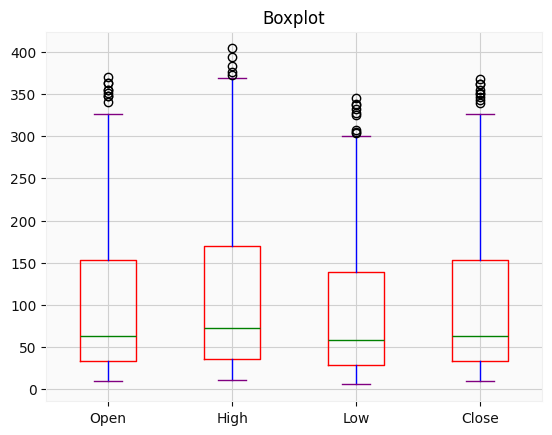

In [153]:

# Create box plot of each column to visualize the distribution

ax= data[col].plot(kind='box',title='Boxplot',color=dict(boxes='red', whiskers='blue', medians='green', caps='purple'))
plt.show()

##### The boxplot for the closing price indicates that the majority of observations fall within the range of approximately 30 to 150, with the median value around 55. Nevertheless, the presence of multiple outliers exceeding 300 suggests that the stock experienced occasional sharp price surges during certain periods.

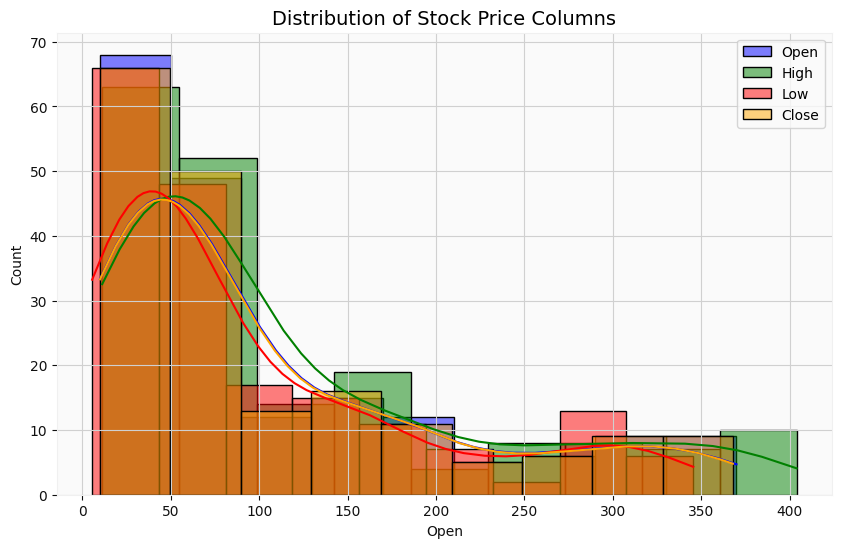

In [ ]:
# Plotting histogram for each column in one chart using different shades

# Set figure size
plt.figure(figsize=(10, 6))


sns.histplot(data['Open'], kde=True, color="blue", label="Open", alpha=0.5)
sns.histplot(data['High'], kde=True, color="green", label="High", alpha=0.5)
sns.histplot(data['Low'], kde=True, color="red", label="Low", alpha=0.5)
sns.histplot(data['Close'], kde=True, color="orange", label="Close", alpha=0.5)

# Set title for better readibility
plt.title("Distribution of Stock Price Columns", fontsize=14)
plt.legend()

# Display the plot
plt.show()


##### The price distributions for the Open, High, Low, and Close variables exhibit a right-skewed pattern, where the majority of values are clustered below 100. The extended tail on the higher end reflects a small number of extreme price observations, which accounts for the outliers identified in the boxplot analysis.

##Bivariate Analysis

**Analyze the relationship between the 'Close' price and other features.**

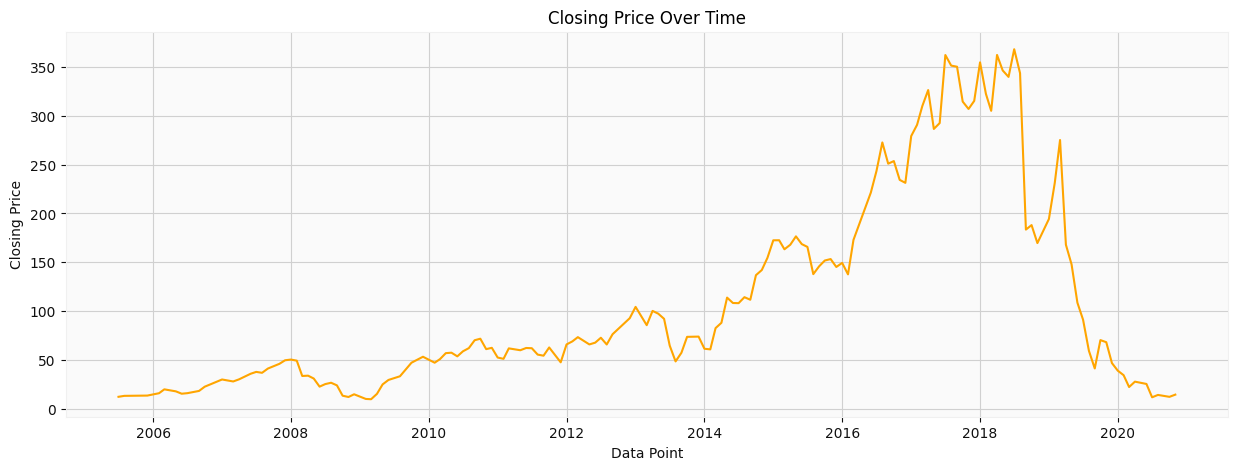

In [149]:
# Line Chart
plt.figure(figsize=(15, 5))
sns.lineplot(x=data.index, y='Close', data=data, color="orange")
plt.title('Closing Price Over Time')
plt.xlabel('Data Point')
plt.ylabel('Closing Price')
plt.show()

##### The closing price trend reflects a period of consistent growth from 2005 up to around 2017, during which the stock reached a peak value of over 350. This upward movement is followed by a steep decline, indicating the occurrence of significant market corrections or the influence of external factors on the stock’s performance.

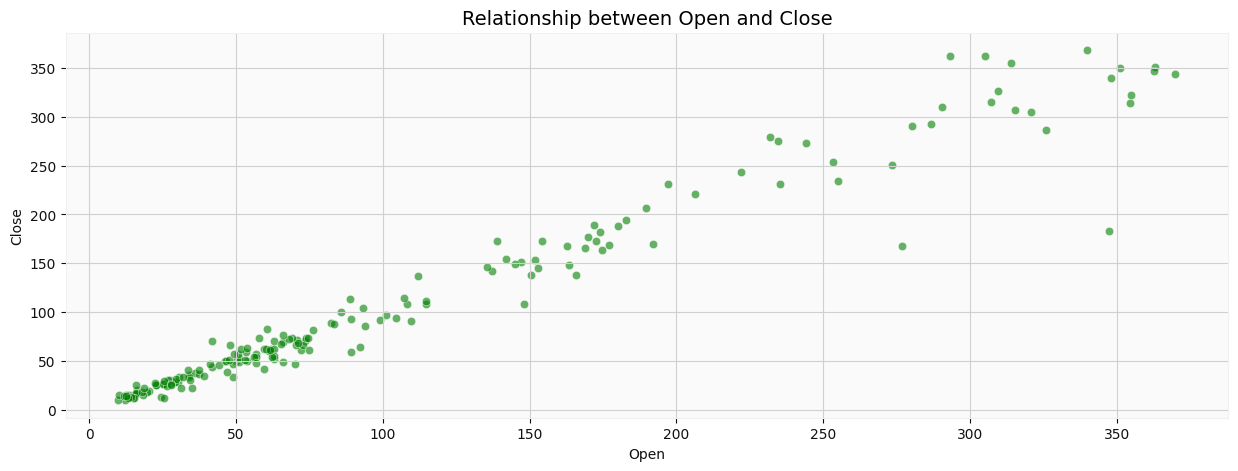

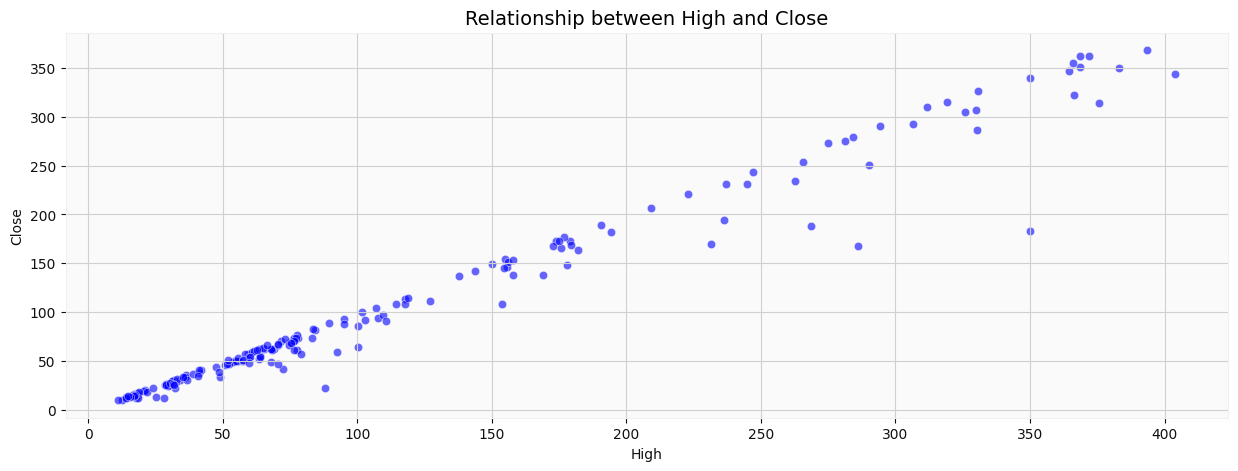

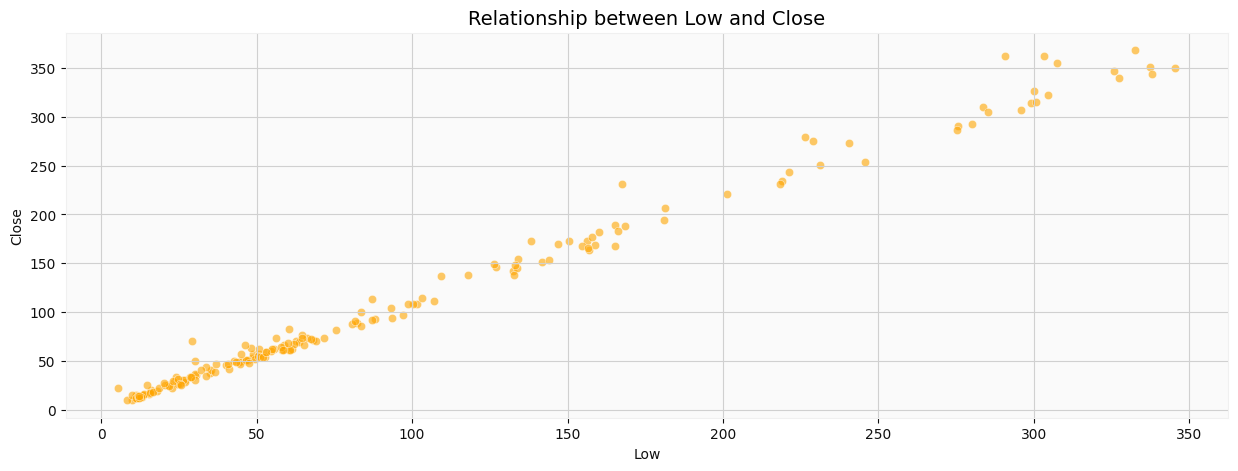

In [ ]:
# Visualize reationship between all the variable with the 'Close' column

colors = ["red", "green", "blue", "orange", "purple", "cyan"]  # cycle of colors

for i, col in enumerate(data.columns):
    if col not in ['Date','Close']:
        plt.figure(figsize=(15, 5))
        sns.scatterplot(x=col, y='Close', data=data, color=colors[i % len(colors)], alpha=0.6)
        plt.title(f'Relationship between {col} and Close', fontsize=14)
        plt.xlabel(col)
        plt.ylabel("Close")
        plt.show()


## (Open vs Close)

##### The scatter plot illustrating the relationship between Open and Close prices shows a strong and nearly linear pattern. As the opening price increases, the closing price also tends to rise correspondingly, indicating a high positive correlation between these two variables.



## (High vs Close)

##### The scatter plot comparing High and Close prices demonstrates a clear linear association, where increases in the high price are accompanied by corresponding rises in the closing price. This pattern indicates a strong positive correlation between the two variables.

## (Low vs Close)

##### In a similar manner, the Low versus Close scatter plot also exhibits a pronounced linear relationship, suggesting that the closing price tends to move closely in line with the daily low values. This observation highlights the strong dependency and close linkage among the stock price variables.

In [ ]:
# Make date as index

data.set_index('Date',inplace=True)
data.head()

In [ ]:
# Install mplfinance library
!pip install mplfinance

import mplfinance as mpf

# Assigning a variable to store all the data of 'Open', 'High', 'Low', 'Close' from the row data
data_candle = data[['Open', 'High', 'Low', 'Close']]

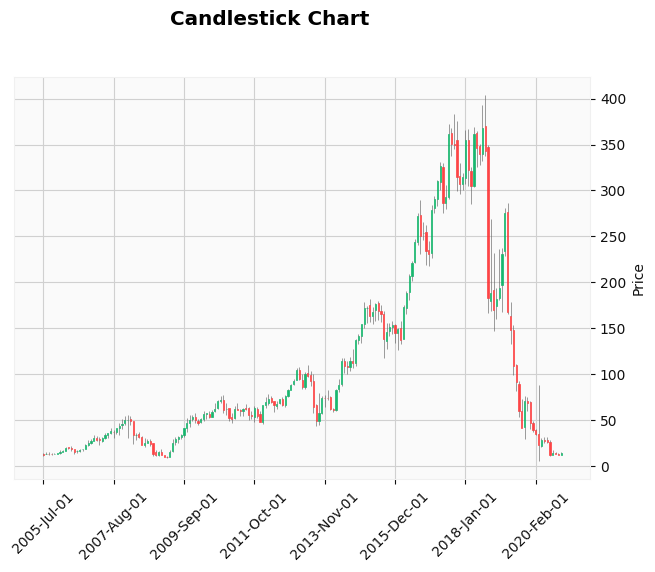

In [ ]:
# creating a candle stick chart to show the stock trends and movements

mpf.plot(data_candle, type='candle', style='yahoo', title='Candlestick Chart')

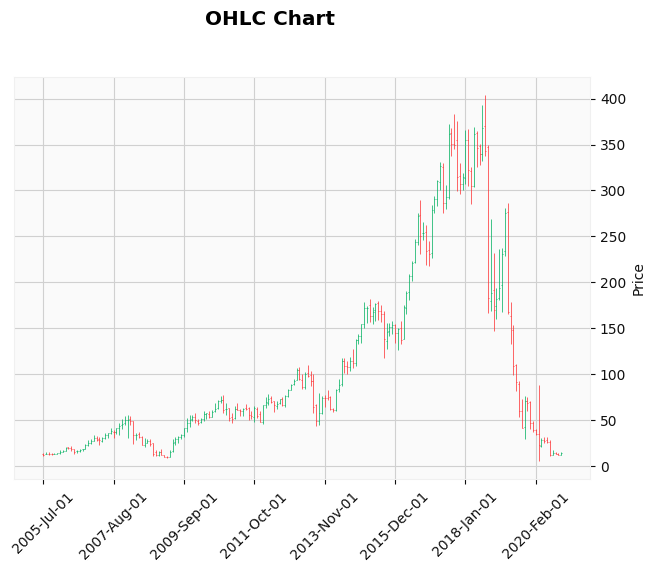

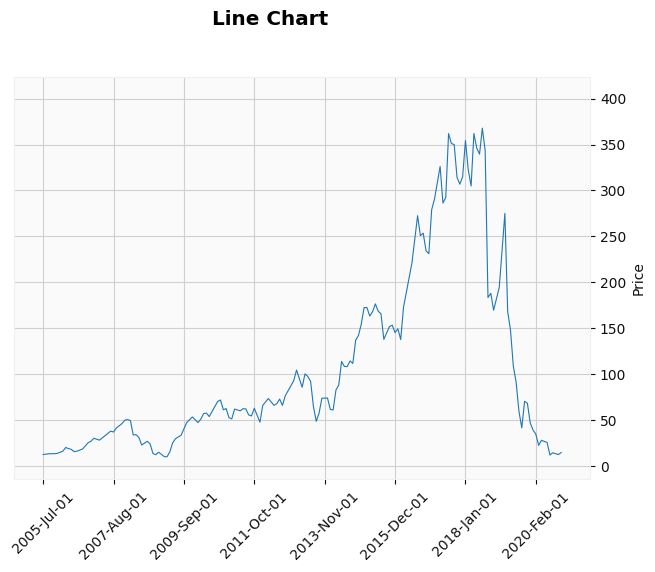

In [ ]:
# Other types: 'ohlc', 'line', 'renko', 'pnf'

mpf.plot(data_candle, type='ohlc', style='yahoo', title='OHLC Chart')
mpf.plot(data_candle, type='line', style='yahoo', title='Line Chart')


##Multivariate Analysis

**Plot a heatmap to visualize correlations.**

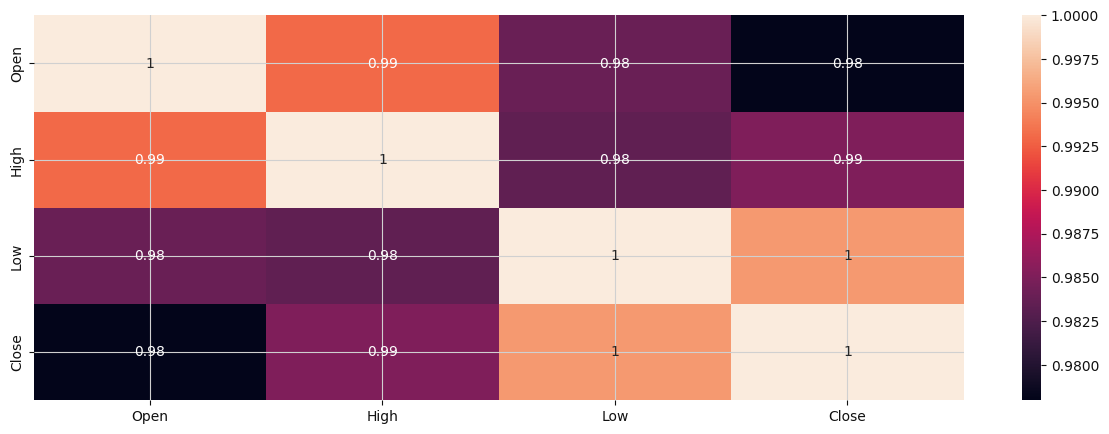

In [ ]:
# creating the heatmap to visualize correaltion

plt.figure(figsize=(15,5))
cor = sns.heatmap(data.corr(),annot=True)

🔄 Handling Multicollinearity


The dataset exhibits strong correlations among several features, suggesting the presence of multicollinearity. Since Linear Regression assumes that independent variables are not highly correlated, this can lead to unstable coefficient estimates and reduced model reliability.

To mitigate this issue, we apply feature transformations to stabilize the data distribution and reduce the impact of multicollinearity.

In [146]:
# Apply power analysis using PowerTransformer

pw = PowerTransformer(method='box-cox',standardize=True)

In [ ]:
# Making a object where we can apply the power analysis transformation

cf= data[list(data.columns)]

In [ ]:
# Performing the poweranalysis transformation on the object where we store the data, in the form of dataframe
# so we can get a tranformed dataframe

kf = pd.DataFrame(pw.fit_transform(cf))

In [166]:
# checking the transformed data

kf.head()

,Open,High,Low,Close
0,-1.671724,-1.762828,-1.622235,-1.709751
1,-1.704449,-1.700176,-1.518365,-1.635775
2,-1.635576,-1.700867,-1.539820,-1.644731
3,-1.656505,-1.728898,-1.529800,-1.668243
4,-1.645239,-1.771672,-1.493670,-1.636518


In [ ]:
# Renaming the columns as they were before transformation

kf.rename(columns={0:'Open',1:'High',2:'Low',3:'Close'},inplace=True)

<Axes: >

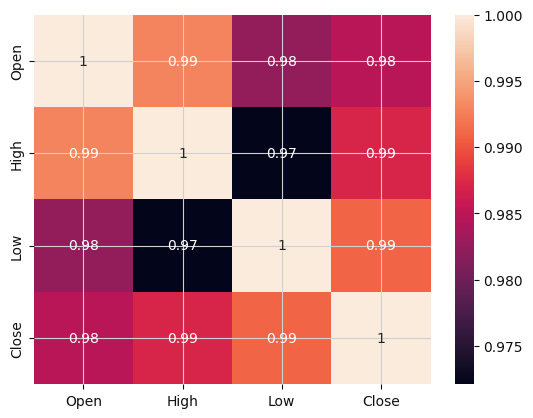

In [145]:
# Visualising the correlation between transformed columns using heatmap

sns.heatmap(kf.corr(),annot=True)

In [ ]:
# creating object of all the columns in a list of transformed data

col = list(kf.columns)

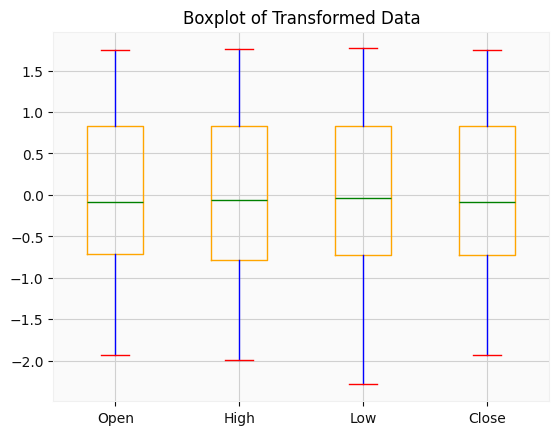

In [ ]:
# now visualise the data by using box plot of transformed data

ax = kf[col].plot(
    kind='box',
    title='Boxplot of Transformed Data',
    color=dict(
        boxes="orange",     # color of the boxes
        whiskers="blue",    # color of whiskers
        medians="green",    # color of median line
        caps="red"          # color of caps
    )
)

plt.show()


##### After applying transformation, the boxplots of all four columns (Open, High, Low, Close) appear more standardized and symmetric, with fewer extreme outliers. This suggests that transformation made the dataset more balanced and suitable for further statistical modeling.

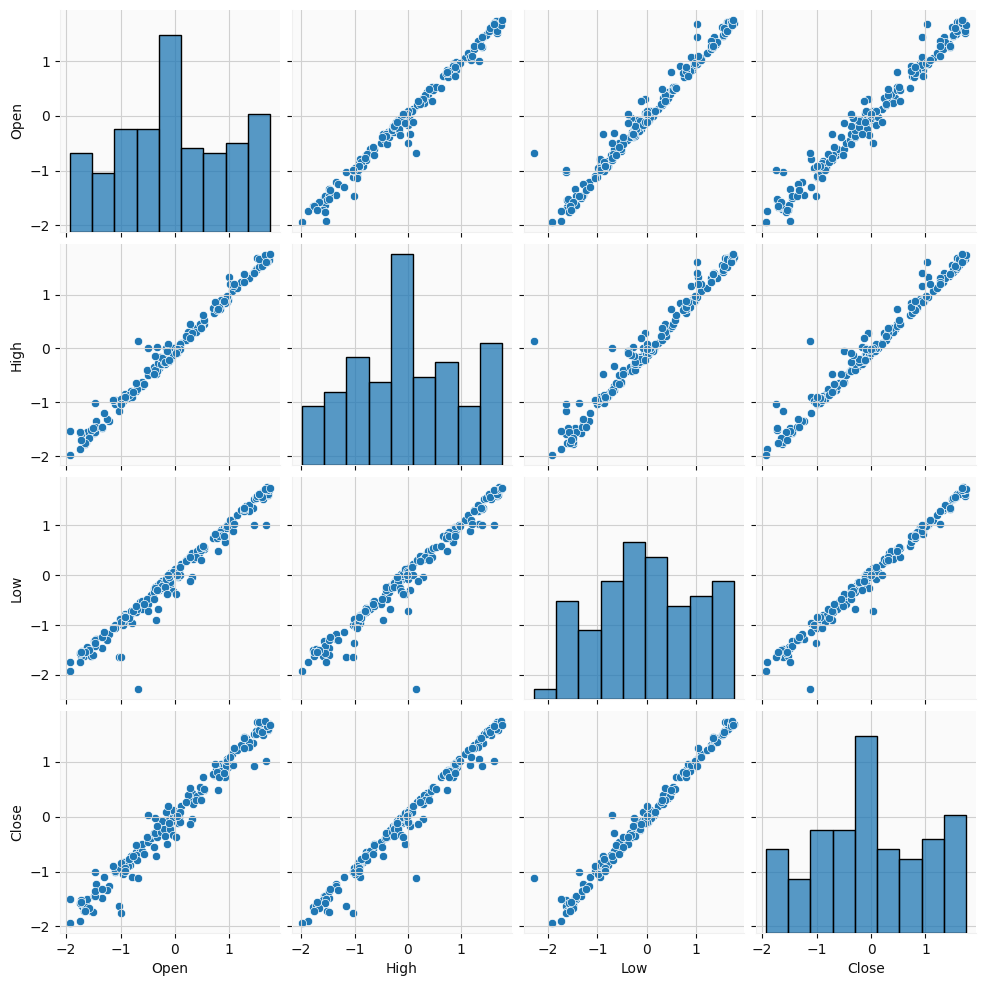

In [ ]:
# Visualize the relationship between diffrent variables of the transformed data using pair plot

sns.pairplot(kf)

#Data Preprocessing



Transform the features using PowerTransformer.

In [142]:
# Top 5 rows view of the transformed data

kf.head()

,Open,High,Low,Close
0,-1.671724,-1.762828,-1.622235,-1.709751
1,-1.704449,-1.700176,-1.518365,-1.635775
2,-1.635576,-1.700867,-1.539820,-1.644731
3,-1.656505,-1.728898,-1.529800,-1.668243
4,-1.645239,-1.771672,-1.493670,-1.636518


In [143]:
# Assigning the dependent variable
dependent_variable = 'Close'

# Assigning independent variables
independent_variable = list(set(kf.columns.tolist())-{dependent_variable})

In [144]:
# Dividing the dataset into two part , X and y
# where X is collection of independent variables , and y is dependent variable

x=data[independent_variable].values
y=data[dependent_variable].values

In [ ]:
# Using train test split to spllit the data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

## Model Building  

To predict stock prices, multiple regression models are applied:  

1. **Linear Regression** – A baseline model to understand linear relationships.  
2. **Ridge Regression** – Adds L2 regularization to handle multicollinearity.  
3. **Lasso Regression** – Uses L1 regularization for feature selection.  
4. **Elastic Net** – A combination of Ridge and Lasso for balanced performance.  
5. **Random Forest Regressor** – A tree-based ensemble method for improved accuracy.  
Each model is evaluated using appropriate metrics to compare performance and select the best one.

# **Linear Regression**

In [ ]:
# Training a Linear Regression model using the transformed dataset

reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Predict the values using test data

y_pred = reg.predict(x_test)

In [ ]:
# Calculate the R square of the model

linear_r2 = r2_score(y_test,y_pred)
linear_r2

0.9930815866308079

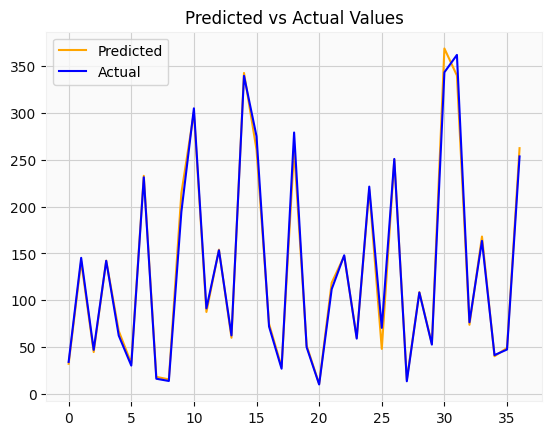

In [ ]:
# Plot graph of predicted values with respect to actual values

plt.plot(y_pred, color="orange")   # predicted in orange
plt.plot(y_test, color="blue")     # actual in blue
plt.legend(["Predicted", "Actual"])
plt.title("Predicted vs Actual Values")
plt.show()

##### The model predictions follow the overall trend of the actual values but fail to capture sharp fluctuations. This indicates that the model is able to learn the general pattern of the data but struggles to accurately model periods of high volatility.

# **K-Nearest Neighbors (KNN):**

In [ ]:
# importing KNN library
from sklearn.neighbors import KNeighborsRegressor

# importing gridsearch
from sklearn.model_selection import GridSearchCV

# creating object of KNN
knn = KNeighborsRegressor()

# randomely taking paramets of n_neighbours
params = {'n_neighbors':[2,3,4,5,6,7,8,9]}

# creating model for gridsearch for getting best parameters with respect to KNN model
model = GridSearchCV(knn,params,cv=5)

In [ ]:
# Running GridSearchCV to find the optimal hyperparameters for the model.

model.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9]})

In [ ]:
# Calculate the best paramets by the gridsearch

model.best_params_

{'n_neighbors': 2}

In [ ]:
# Performing KNN regression by using that parameter

knn = KNeighborsRegressor(n_neighbors=2)

In [ ]:
# Fitting the model by using transofrmed data

knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=2)

In [ ]:
# Predicting by using KNN model

knn_pred = knn.predict(x_test)

In [ ]:
# caculating R square value of the model

r2_knn = r2_score(y_test,knn_pred)
r2_knn

0.9931154527450295

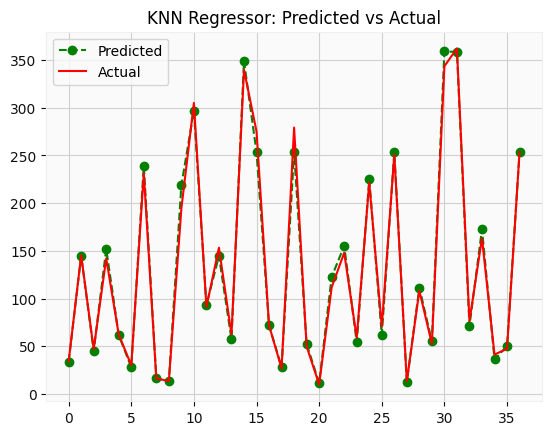

In [ ]:
# Visualization of the Knn prediction with the acutal data points

plt.plot(knn_pred, color="green", linestyle="--", marker="o")   # predicted in green dashed line
plt.plot(y_test, color="red", linestyle="-")                    # actual in red solid line
plt.legend(["Predicted", "Actual"])
plt.title("KNN Regressor: Predicted vs Actual")
plt.show()


##### The KNN regressor predictions closely follow the actual values, successfully capturing both sharp increases and sudden declines in the data. This suggests that the KNN model performs better than Linear Regression for this dataset, particularly in modeling non-linear patterns and fluctuations.

# **RandomForest**

In [ ]:
# Using GridSearchCV to tune Random Forest hyperparameters and find the best performing model.

rf = RandomForestRegressor()
params = {'n_estimators':[100,200,300],'criterion':['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],'max_features':['sqrt', 'log2', None]}
rf_model = GridSearchCV(rf,params,cv=5)

In [ ]:
# Fitting the Ridge Regression model on the training data to learn the relationship
# between independent variables and the target variable while controlling overfitting.

rf_model.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_features': ['sqrt', 'log2', None],
                         'n_estimators': [100, 200, 300]})

In [ ]:
# Calculate best params

rf_model.best_params_

{'criterion': 'poisson', 'max_features': None, 'n_estimators': 300}

In [ ]:
# fitting the model by using parameters what gridsearch showed

rf = RandomForestRegressor(criterion= 'friedman_mse', max_features= None, n_estimators= 300)

In [ ]:
# Fitting the Ridge Regression model on the training data to learn the relationship
# between independent variables and the target variable while controlling overfitting.

rf.fit(x_train,y_train)

RandomForestRegressor(criterion='friedman_mse', max_features=None,
                      n_estimators=300)

In [ ]:
# Predict by using test data

rf_predict_ = rf.predict(x_test)

In [ ]:
# Calculate R square value for the random forest model

rf_r2 = r2_score(y_test,rf_predict_)
rf_r2

0.9855957972794123

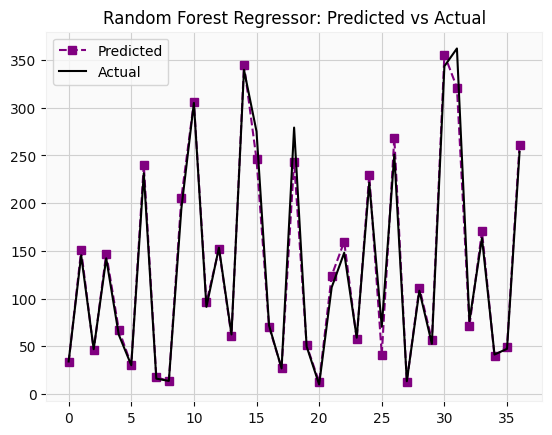

In [ ]:
# Visualize the actual and predicted datapoints

plt.plot(rf_predict_, color="purple", linestyle="--", marker="s")  # predicted in purple dashed line with square markers
plt.plot(y_test, color="black", linestyle="-")                     # actual in black solid line
plt.legend(["Predicted", "Actual"])
plt.title("Random Forest Regressor: Predicted vs Actual")
plt.show()


#### The Random Forest regressor predictions closely match the actual values, successfully capturing both the overall trend and sudden fluctuations in the data. This demonstrates that the model provides strong predictive performance and is more robust compared to simpler models.

# **Ridge Regression**

In [ ]:
# Initializing Lasso regression model and tuning hyperparameters using GridSearchCV

ridge =Ridge()
param = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,0.3,0.7,1,1.2,1.33,1.365,1.37,1.375,1.4,1.5,1.6,1.8,2.5,5,10,20,30,40,45,50,55,60,100]}
ridge_regressor = GridSearchCV(ridge, param, scoring='neg_mean_squared_error', cv=3)
ridge_regressor.fit(x_train,y_train)
ridge_regressor.best_params_

{'alpha': 100}

In [ ]:
# Store alpha values in ridge

ridge =Ridge(alpha= 100)

In [ ]:
# Fitting the ridge regression on training data by passing x_train and y_train

ridge.fit(x_train,y_train)

Ridge(alpha=100)

In [ ]:
# Generating closing price predictions on the test set

y_pred_ridge = ridge.predict(x_test)

In [ ]:
# caculating R square value for the ridge regression model

ridge_r2 = r2_score(y_test,y_pred_ridge)
ridge_r2

0.9930447012730752

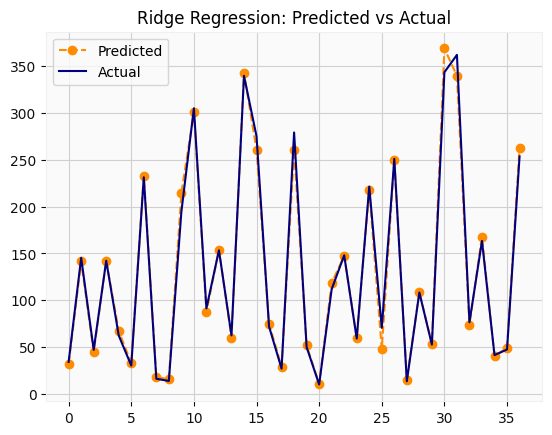

In [ ]:
# lets visualize the graph of actual and and predicted datapoints

plt.plot(y_pred_ridge, color="darkorange", linestyle="--", marker="o")  # predicted in orange dashed line with circle markers
plt.plot(y_test, color="navy", linestyle="-")                           # actual in navy solid line
plt.legend(["Predicted", "Actual"])
plt.title("Ridge Regression: Predicted vs Actual")
plt.show()


##### The Ridge Regression predictions closely align with the actual values, with only minor deviations at extreme peaks and dips. This suggests that Ridge Regression handles fluctuations more effectively than simple Linear Regression while also reducing the risk of overfitting.

# **Lasso**

In [ ]:
# Initializing Lasso regression model and tuning hyperparameters using GridSearchCV

lasso =Lasso()
param = {'alpha': [1e-15,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,0.3,0.7,1,1.2,1.33,1.365,1.37,1.375,1.4,1.5,1.6,1.8,2.5,5,10,20,30,40,45,50,55,60,100]}
lasso_regressor = GridSearchCV(lasso, param, scoring='neg_mean_squared_error', cv=3)
lasso_regressor.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 1e-05, 0.0001, 0.001,
                                   0.01, 0.3, 0.7, 1, 1.2, 1.33, 1.365, 1.37,
                                   1.375, 1.4, 1.5, 1.6, 1.8, 2.5, 5, 10, 20,
                                   30, 40, 45, 50, 55, 60, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
# Display the best parameters

lasso_regressor.best_params_

{'alpha': 1.6}

In [ ]:
# Using best hyperparameter assigning the model

lasso =Lasso(alpha= 2.5)

In [ ]:
# Fitting the lasso regression on training data by passing x_train and y_train

lasso.fit(x_train,y_train)

Lasso(alpha=2.5)

In [ ]:
# Generating closing price predictions on the test set

lasso_predict = lasso.predict(x_test)

In [ ]:
# caculating R square of the model

lasso_r2 = r2_score(lasso_predict,y_test)
lasso_r2

0.9926310359702802

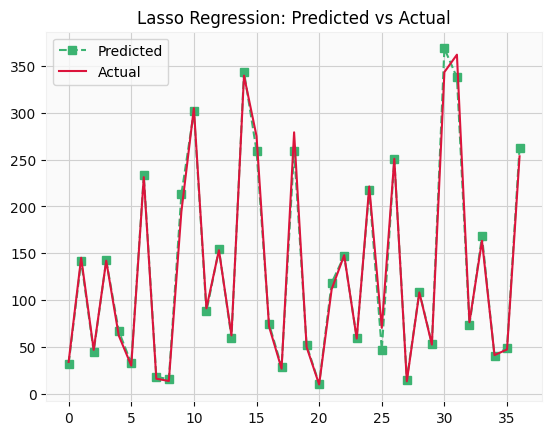

In [ ]:
# Visualize the difference in result

plt.plot(lasso_predict, color="mediumseagreen", linestyle="--", marker="s")  # predicted in green dashed with square markers
plt.plot(y_test, color="crimson", linestyle="-")                             # actual in crimson solid line
plt.legend(["Predicted", "Actual"])
plt.title("Lasso Regression: Predicted vs Actual")
plt.show()

##### Lasso Regression predictions are closely aligned with actual values, effectively capturing the overall trend. However, it slightly smooths out sharp fluctuations, showing its tendency to simplify the model by shrinking less important features.

# **Elasticnet**

In [ ]:
# Initializing ElasticNet model and tuning hyperparameters using GridSearchCV


elastic =ElasticNet()
param = {'alpha': [1e-15,1e-13,1e-10,1e-8,1e-5,1e-4,1e-3,0.001,0.01,0.02,0.03,0.04,1,5,10,20,40,50,60,100],
                          'l1_ratio':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]}
elastic_regressor = GridSearchCV(elastic, param, scoring='neg_mean_squared_error', cv=5)
elastic_regressor.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [1e-15, 1e-13, 1e-10, 1e-08, 1e-05, 0.0001,
                                   0.001, 0.001, 0.01, 0.02, 0.03, 0.04, 1, 5,
                                   10, 20, 40, 50, 60, 100],
                         'l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                      0.9]},
             scoring='neg_mean_squared_error')

In [ ]:
# Display the best parameter of elasticnet regression model

elastic_regressor.best_params_

{'alpha': 5, 'l1_ratio': 0.1}

In [ ]:
# using these hyperparameter to customise the model

elastic =ElasticNet(alpha = 5, l1_ratio = 0.1)

In [ ]:
# Fitting the ElasticNet model on training data by passing x_train and y_train

elastic.fit(x_train,y_train)

ElasticNet(alpha=5, l1_ratio=0.1)

In [ ]:
# Generating closing price predictions on the test set using the trained ElasticNet model

elastic_predict = elastic.predict(x_test)

In [ ]:
# caculating the R square value for the model
elastic_r2 = r2_score(elastic_predict,y_test)
elastic_r2

0.9927016114818802

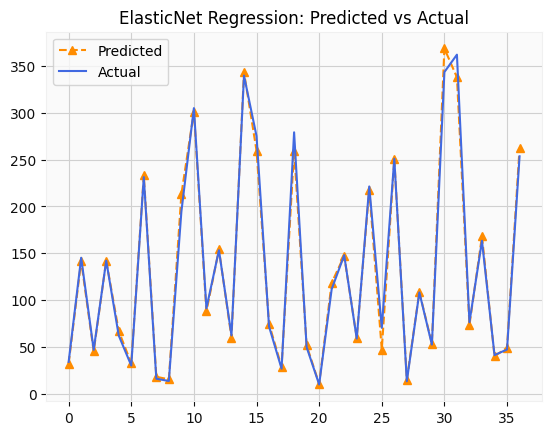

In [ ]:
# Visualizing ElasticNet Regression predictions against actual closing prices
# A close alignment between the two lines indicates strong model performance

plt.plot(elastic_predict, color="darkorange", linestyle="--", marker="^")  # Predicted in orange wth small triangle
plt.plot(y_test, color="royalblue", linestyle="-")                         # Denotes Actual with blue
plt.legend(["Predicted", "Actual"])
plt.title("ElasticNet Regression: Predicted vs Actual")
plt.show()

ElasticNet combines Ridge (L2) and Lasso (L1) regularization, balancing between feature shrinkage and elimination. The predicted values align closely with actual closing prices, capturing both trend and fluctuations effectively — making it a stable, well-generalized model. With an R² score of 0.9927, it holds a competitive position among all models tested.

# **Evaluation and Improvement of Model**

In [ ]:
# Creating dataframe of differeent models with their r2_score

Report = pd.DataFrame(data={'model':['linear regression','ridge regression','lasso regression','elastic net regression','knn regression','RandomForest Regression'],'r2_score':[linear_r2,ridge_r2,lasso_r2,elastic_r2,r2_knn,rf_r2]})


In [ ]:
# Display model with their respective r2_score

Report.sort_values(by=['r2_score'],ascending=False,inplace=True)
Report

,model,r2_score
4,knn regression,0.993115
0,linear regression,0.993082
1,ridge regression,0.993045
3,elastic net regression,0.992702
2,lasso regression,0.992631
5,RandomForest Regression,0.985596


📊 Model Evaluation Summary

Six regression models were trained and evaluated on the Yes Bank stock price dataset.
All models delivered exceptional predictive performance, with R² scores above 0.98 across the board.

🏆 KNN Regression emerged as the top performer with an R² score of 0.9931,
effectively capturing both the overall price trend and sharp market fluctuations.

Linear Regression and Ridge Regression followed closely at 0.9931 and 0.9930 respectively,
proving that even simpler models perform remarkably well when the underlying data has strong linear relationships.

ElasticNet and Lasso Regression maintained solid performance at 0.9927 and 0.9926,
demonstrating that regularization techniques preserve accuracy while keeping the model generalized.

Random Forest Regression, despite being the most complex ensemble model in this comparison,
scored 0.9855 — slightly lower than the rest, but still an outstanding result.

💡 Key Takeaway: The marginal performance gap between all models suggests that the
strong linear correlation among stock price variables (Open, High, Low → Close)
makes this a well-structured prediction problem where even baseline models excel.

##**Feature Importance:**

For Random Forest and other applicable models, determine feature importance.

In [ ]:
# Assuming you have already run GridSearchCV and fitted the model
rf_best = rf_model.best_estimator_

# Extract feature importance
feature_importance = pd.Series(rf_best.feature_importances_, index=independent_variable).sort_values(ascending=False)

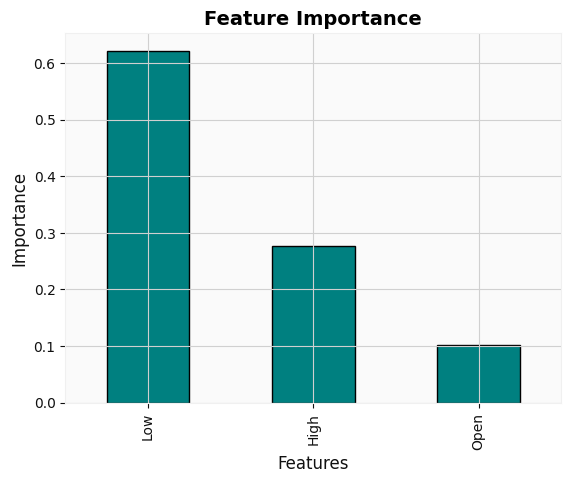

In [ ]:
# Plot feature importances

feature_importance.plot(
    kind='bar',
    color="teal",
    edgecolor="black"      # outline for better visibility
)
plt.title('Feature Importance', fontsize=14, fontweight="bold")
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.show()

# **Conclusions Drawn :**

📊 Project Conclusions – Yes Bank Stock Price Prediction

📅 The dataset contains 185 monthly stock price records of Yes Bank, spanning from July 2005 to November 2020.

⚖️ A significant price crash is observed post-2018, directly attributed to the fraud case involving Rana Kapoor, which severely impacted investor confidence.

✅ The dataset was found to be clean with no missing values or duplicate records, making it ready for modeling without extensive data cleaning.

📉 Outliers were intentionally retained to preserve the natural volatility patterns of the stock, which are critical for accurate price prediction.

🔄 Power Transformation (Box-Cox method) was applied to handle the right-skewed distribution of price features and reduce multicollinearity among independent variables.

📈 Strong positive correlation was observed between all price variables — Open, High, Low, and Close — indicating high prediction potential.

🏆 Model Performance Summary:

| Model                   | R² Score |
|-------------------------|----------|
| KNN Regression          | 0.9931   |
| Linear Regression       | 0.9931   |
| Ridge Regression        | 0.9930   |
| ElasticNet Regression   | 0.9927   |
| Lasso Regression        | 0.9926   |
| Random Forest           | 0.9856   |

Among all six models, KNN Regressor delivered the best performance with an R² score of 0.9931, closely followed by Linear Regression, Ridge, ElasticNet, and Lasso. Random Forest, despite being a powerful ensemble method, performed slightly lower at 0.9856.

✔️ Overall, all models performed exceptionally well, validating that regression-based techniques are highly effective for stock price prediction on this dataset.

##📌 Project Utility for Stakeholders

💹 Investor Decision-Making:
Accurate prediction of Yes Bank's closing prices empowers investors to make data-driven, informed buy or sell decisions — reducing reliance on speculation.

📊 Event Impact Analysis:
The model demonstrates how major corporate events, such as the 2018 Rana Kapoor fraud case, directly translate into quantifiable stock price movements — giving analysts a framework to assess risk around future events.

📈 Financial Strategy & Planning:
The predictive framework built in this project serves as a foundation for broader financial analysis, portfolio management, and long-term investment strategy formulation.

🏦 Banking Sector Insights:
For financial institutions and market regulators, this kind of model provides early warning signals about stock instability, enabling proactive risk management.

🤖 Scalability:
The regression pipeline developed here can be extended to predict stock prices of other listed companies — making it a reusable, scalable solution for the financial analytics domain.

Thank you !
